In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load master table
master = pd.read_csv(DATA_PROCESSED / 'master.csv')
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'])

# Load reviews separately — it's not in master
reviews = pd.read_csv(DATA_RAW / 'olist_order_reviews_dataset.csv')

print(f"master:  {master.shape[0]:,} rows")
print(f"reviews: {reviews.shape[0]:,} rows")

master:  110,197 rows
reviews: 99,224 rows


In [4]:
snapshot_date=master['order_purchase_timestamp'].max()+pd.Timedelta(days=1)

rfm=(master.groupby('customer_unique_id')
     .agg(recency=('order_purchase_timestamp',lambda x:(snapshot_date-x.max()).days),
          frequency=('order_id','nunique'),
          monetary=('payment_value','sum'))
          .reset_index())

#Score each dimension 1-5 using qunitiles
rfm['R']=pd.qcut(rfm['recency'],q=5,labels=[5,4,3,2,1]).astype(int)
rfm['F']=pd.qcut(rfm['frequency'].rank(method='first'),q=5,labels=[1,2,3,4,5]).astype(int)
rfm['M']=pd.qcut(rfm['monetary'],q=5,labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score']=rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)
rfm['RFM_Total']=rfm['R']+rfm['F']+rfm['M']

In [5]:
def segment_customer(row):
    r,f,m=row['R'],row['F'],row['M']
    if r>=4 and f>=4 and m>=4:
        return 'Champions'
    elif r>=3 and f>=3:
        return 'Loyal Customers'
    elif r>=4 and f<=2:
        return 'At Risk'
    elif r>=3 and f>=2 and m>=3:
        return 'Potential Loyalists'
    elif r==3 and f<=1:
        return 'At Risk'
    elif r<=2 and f>=2:
        return 'Cannot Lose Them'
    elif r<=2 and f==1 and m>=3:
        return 'Hibernating'
    else:
        return 'Lost'
    
rfm['Segment']=rfm.apply(segment_customer,axis=1)

#Summary by segment
segment_summary=rfm.groupby('Segment').agg(
    customer_count=('customer_unique_id','count'),
    avg_monetary=('monetary','mean'),
    avg_recency=('recency','mean'),
).round(2).sort_values('avg_monetary',ascending=False)

print(segment_summary)
rfm.to_csv(DATA_PROCESSED / 'rfm_segments.csv', index=False)

                     customer_count  avg_monetary  avg_recency
Segment                                                       
Champions                      6460        442.08        91.05
Hibernating                    4356        334.90       397.45
Potential Loyalists            2161        279.27       221.11
Cannot Lose Them              29733        211.87       394.57
At Risk                       18694        201.77       116.42
Loyal Customers               27325        165.71       144.18
Lost                           4629         55.89       338.87


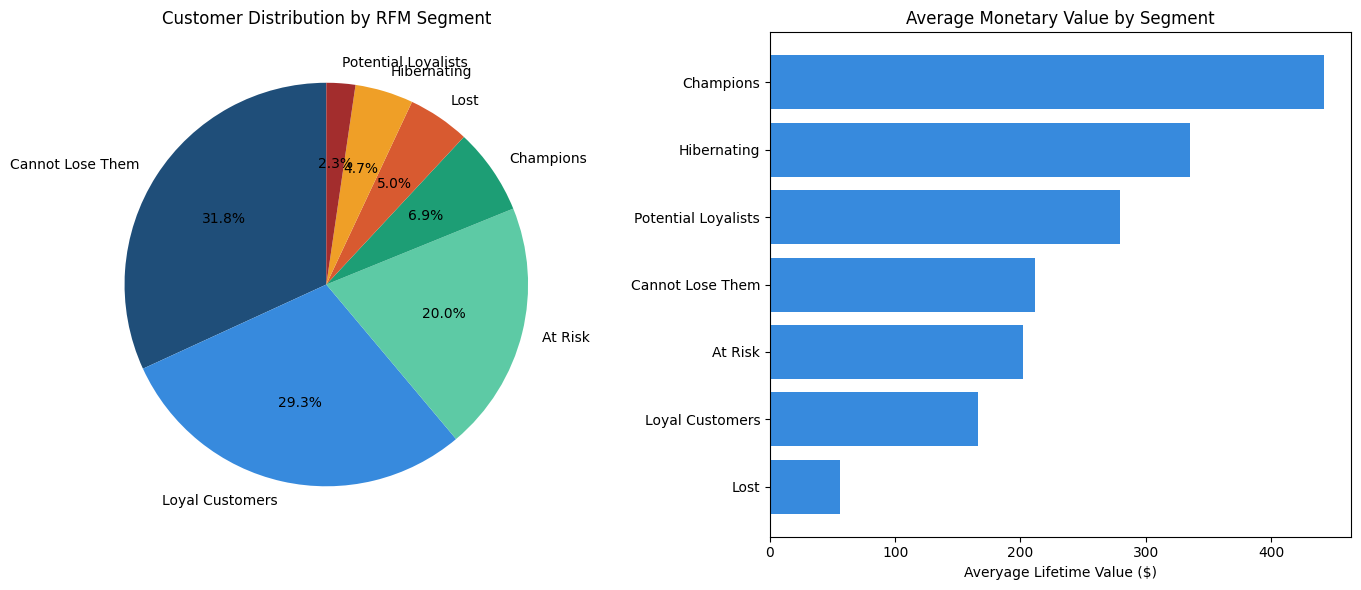

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

seg_counts=rfm['Segment'].value_counts()

colors=['#1F4E79','#378ADD','#5DCAA5','#1D9E75','#D85A30',
          '#EF9F27','#A32D2D','#888780']

fig,axes=plt.subplots(1,2,figsize=(14,6))

#Pie Chart
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Customer Distribution by RFM Segment')

#Bar Chart
seg_monetary=rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=True)
axes[1].barh(seg_monetary.index, seg_monetary.values,color="#378ADD")
axes[1].set_xlabel("Averyage Lifetime Value ($)")
axes[1].set_title('Average Monetary Value by Segment')

plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'rfm_segments.png',dpi=150,bbox_inches='tight')
